In [1]:
%load_ext autoreload
%autoreload 2
%pip install optuna

import sys
import os
import pandas as pd
import numpy as np

# Se till att notebooken hittar källkoden i src-mappen
sys.path.append(os.path.abspath('../'))
from src.data_loader import download_stock_data, download_macro_and_market_data, get_data_path

# 1. Lista på alla aktier
omxs30_tickers = [
    'ABB.ST', 'ADDT-B.ST', 'ALFA.ST', 'ASSA-B.ST', 'AZN.ST',
    'ATCO-A.ST', 'BOL.ST', 'EPI-A.ST', 'EQT.ST', 'ERIC-B.ST',
    'ESSITY-B.ST', 'EVO.ST', 'SHB-A.ST', 'HM-B.ST', 'HEXA-B.ST',
    'INDU-C.ST', 'INVE-B.ST', 'LIFCO-B.ST', 'NIBE-B.ST', 'NDA-SE.ST',
    'SAAB-B.ST', 'SAND.ST', 'SCA-B.ST', 'SEB-A.ST', 'SKA-B.ST',
    'SKF-B.ST', 'SWED-A.ST', 'TEL2-B.ST', 'TELIA.ST', 'VOLV-B.ST'
]

# 2. Hämta rådata (Aktier och Makro)
df_prices = download_stock_data(tickers=omxs30_tickers, start_date='2015-01-01', end_date='2026-01-01')
df_global_data = download_macro_and_market_data(start_date='2015-01-01', end_date='2026-01-01')

# 3. Gör om till månadsdata (OBS: dropna() är borttagen härifrån!)
df_monthly_returns = df_prices.resample('ME').last().pct_change()
df_monthly_global = df_global_data.resample('ME').last()

# 4. Skapa shifted target variable (Relativ avkastning nästa månad)
omxs30_return_next = df_monthly_global['OMXS30_Index'].pct_change().shift(-1)
df_target = df_monthly_returns.shift(-1).sub(omxs30_return_next, axis=0)

# 5. Beräkna rullande features i wide format
df_momentum_3M = df_monthly_returns.rolling(3).sum()
df_volatility_3M = df_monthly_returns.rolling(3).std()
df_omxs30_momentum_3M = df_monthly_global['OMXS30_Index'].pct_change().rolling(3).sum()

# 6. Transformera target till long format
df_target_long = df_target.reset_index().melt(
    id_vars='Date', 
    var_name='Ticker', 
    value_name='Target_Next_Month_Relative_Return'
)

# 7. Transformera momentum 1M till 12M till long format och slå ihop
momentum_feature_frames = []
for months in range(1, 13):
    df_momentum_month = df_monthly_returns.rolling(months).sum()
    df_momentum_long = df_momentum_month.reset_index().melt(
        id_vars='Date', 
        var_name='Ticker', 
        value_name=f'Feature_Momentum_{months}M'
    )
    momentum_feature_frames.append(df_momentum_long)

df_stock_features_long = momentum_feature_frames[0]
for df_feature in momentum_feature_frames[1:]:
    df_stock_features_long = pd.merge(df_stock_features_long, df_feature, on=['Date', 'Ticker'])

# Lägg till 3M volatilitet
df_volatility_long = df_volatility_3M.reset_index().melt(
    id_vars='Date', 
    var_name='Ticker', 
    value_name='Feature_Volatility_3M'
)

# 8. Relativt momentum och räntekänslighet
df_momentum_3M_long = df_momentum_3M.reset_index().melt(
    id_vars='Date', 
    var_name='Ticker', 
    value_name='Feature_Momentum_3M'
)

df_omxs30_momentum_long = df_omxs30_momentum_3M.reset_index()
df_omxs30_momentum_long.columns = ['Date', 'OMXS30_Momentum_3M']

df_relative_momentum_long = pd.merge(df_momentum_3M_long, df_omxs30_momentum_long, on='Date', how='left')
df_relative_momentum_long['Feature_Relative_Momentum_3M'] = df_relative_momentum_long['Feature_Momentum_3M'] - df_relative_momentum_long['OMXS30_Momentum_3M']
df_relative_momentum_long = df_relative_momentum_long[['Date', 'Ticker', 'Feature_Relative_Momentum_3M']]

df_rate_sensitivity_long = pd.merge(
    df_momentum_3M_long[['Date', 'Ticker', 'Feature_Momentum_3M']],
    df_monthly_global.reset_index()[['Date', 'US10Y']],
    on='Date',
    how='left'
)
df_rate_sensitivity_long['Feature_Mom3M_x_US10Y'] = df_rate_sensitivity_long['Feature_Momentum_3M'] * df_rate_sensitivity_long['US10Y']
df_rate_sensitivity_long = df_rate_sensitivity_long[['Date', 'Ticker', 'Feature_Mom3M_x_US10Y']]

# 9. Slå ihop all aktiedata och makrodata till paneldata
df_stocks_long = pd.merge(df_target_long, df_stock_features_long, on=['Date', 'Ticker'])
df_stocks_long = pd.merge(df_stocks_long, df_volatility_long, on=['Date', 'Ticker'])
df_stocks_long = pd.merge(df_stocks_long, df_relative_momentum_long, on=['Date', 'Ticker'])
df_stocks_long = pd.merge(df_stocks_long, df_rate_sensitivity_long, on=['Date', 'Ticker'])

df_macro_reset = df_monthly_global.reset_index()
df_panel = pd.merge(df_stocks_long, df_macro_reset, on='Date')

# 10. SÄKERT SLUTSTEG: Rensa NaN först nu när datan ligger på höjden
df_panel = df_panel.dropna().reset_index(drop=True)

# Exportera
df_panel.to_excel(get_data_path('omxs30_paneldata_slutgiltig.xlsx'), index=False)

print(f"Done! The panel data has been created with a total of {df_panel.shape[0]} rows.")


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Fetching data for 30 assets from Yahoo Finance...


[*********************100%***********************]  30 of 30 completed


Fetching global market and macro data (VIX, rates, currencies, commodities, indices)...


[*********************100%***********************]  8 of 8 completed


Done! The panel data has been created with a total of 3442 rows.


In [2]:
!pip3 install openpyxl

df_combined = df_monthly_returns.join(df_monthly_global, how='inner')

df_combined.to_excel(get_data_path('omxs30_och_makrodata.xlsx'))

print("Done! The file 'omxs30_och_makrodata.xlsx' has been created in data/.")


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Done! The file 'omxs30_och_makrodata.xlsx' has been created in data/.


In [3]:
import pandas as pd
import numpy as np
from src.data_loader import get_data_path

# Create the shifted target variable as next month's relative return
# Relative return = stock return - OMXS30 return
omxs30_return_next = df_monthly_global['OMXS30_Index'].pct_change().shift(-1)
df_target = df_monthly_returns.shift(-1).sub(omxs30_return_next, axis=0)

# stock-specific rolling features
df_momentum_3M = df_monthly_returns.rolling(3).sum()
df_volatility_3M = df_monthly_returns.rolling(3).std()
df_omxs30_momentum_3M = df_monthly_global['OMXS30_Index'].pct_change().rolling(3).sum()

# Transform the stock target from wide to long format
df_target_long = df_target.reset_index().melt(
    id_vars='Date', 
    var_name='Ticker', 
    value_name='Target_Next_Month_Relative_Return'
)

# Transform momentum 1M to 12M into long format and merge them
momentum_feature_frames = []
for months in range(1, 13):
    df_momentum_month = df_monthly_returns.rolling(months).sum()
    df_momentum_long = df_momentum_month.reset_index().melt(
        id_vars='Date', 
        var_name='Ticker', 
        value_name=f'Feature_Momentum_{months}M'
    )
    momentum_feature_frames.append(df_momentum_long)

df_stock_features_long = momentum_feature_frames[0]
for df_feature in momentum_feature_frames[1:]:
    df_stock_features_long = pd.merge(df_stock_features_long, df_feature, on=['Date', 'Ticker'])

# Add 3M volatility
df_volatility_long = df_volatility_3M.reset_index().melt(
    id_vars='Date', 
    var_name='Ticker', 
    value_name='Feature_Volatility_3M'
 )

# 6. Add relative momentum and momentum x rate sensitivity
df_momentum_3M_long = df_momentum_3M.reset_index().melt(
    id_vars='Date', 
    var_name='Ticker', 
    value_name='Feature_Momentum_3M'
 )

df_omxs30_momentum_long = df_omxs30_momentum_3M.reset_index()
df_omxs30_momentum_long.columns = ['Date', 'OMXS30_Momentum_3M']

df_relative_momentum_long = pd.merge(df_momentum_3M_long, df_omxs30_momentum_long, on='Date', how='left')
df_relative_momentum_long['Feature_Relative_Momentum_3M'] = df_relative_momentum_long['Feature_Momentum_3M'] - df_relative_momentum_long['OMXS30_Momentum_3M']
df_relative_momentum_long = df_relative_momentum_long[['Date', 'Ticker', 'Feature_Relative_Momentum_3M']]

df_rate_sensitivity_long = pd.merge(
    df_momentum_3M_long[['Date', 'Ticker', 'Feature_Momentum_3M']],
    df_monthly_global.reset_index()[['Date', 'US10Y']],
    on='Date',
    how='left'
 )
df_rate_sensitivity_long['Feature_Mom3M_x_US10Y'] = df_rate_sensitivity_long['Feature_Momentum_3M'] * df_rate_sensitivity_long['US10Y']
df_rate_sensitivity_long = df_rate_sensitivity_long[['Date', 'Ticker', 'Feature_Mom3M_x_US10Y']]

# Merge all stock-specific features together
df_stocks_long = pd.merge(df_target_long, df_stock_features_long, on=['Date', 'Ticker'])
df_stocks_long = pd.merge(df_stocks_long, df_volatility_long, on=['Date', 'Ticker'])
df_stocks_long = pd.merge(df_stocks_long, df_relative_momentum_long, on=['Date', 'Ticker'])
df_stocks_long = pd.merge(df_stocks_long, df_rate_sensitivity_long, on=['Date', 'Ticker'])

# Merge with the macro data by date
df_macro_reset = df_monthly_global.reset_index()
df_panel = pd.merge(df_stocks_long, df_macro_reset, on='Date')

# Remove rows with NaN values
df_panel = df_panel.dropna().reset_index(drop=True)

#Export the new structure to Excel
df_panel.to_excel(get_data_path('omxs30_paneldata_slutgiltig.xlsx'), index=False)

print(f"Done! The panel data has been created with a total of {df_panel.shape[0]} rows.")
print("Open data/omxs30_paneldata_slutgiltig.xlsx to review the result.")

Done! The panel data has been created with a total of 3442 rows.
Open data/omxs30_paneldata_slutgiltig.xlsx to review the result.


In [4]:
from sklearn.preprocessing import StandardScaler

# Ensure the date column has the correct format and strict chronological order
df_panel['Date'] = pd.to_datetime(df_panel['Date'])
df_panel = df_panel.sort_values(['Date', 'Ticker']).reset_index(drop=True)

# Create a time split (train through 2022, test from 2023 onward)
train_mask = df_panel['Date'] < '2023-01-01'
test_mask = df_panel['Date'] >= '2023-01-01'

df_train = df_panel[train_mask].copy()
df_test = df_panel[test_mask].copy()

# Keep raw copies for leakage-safe XGBoost CV/training.
df_train_raw = df_train.copy()
df_test_raw = df_test.copy()

# Features (X) and target (y)
feature_cols = [
    'Feature_Momentum_1M',
    'Feature_Momentum_2M',
    'Feature_Momentum_3M',
    'Feature_Momentum_4M',
    'Feature_Momentum_5M',
    'Feature_Momentum_6M',
    'Feature_Momentum_7M',
    'Feature_Momentum_8M',
    'Feature_Momentum_9M',
    'Feature_Momentum_10M',
    'Feature_Momentum_11M',
    'Feature_Momentum_12M',
    'Feature_Volatility_3M',
    'Feature_Relative_Momentum_3M',
    'Feature_Mom3M_x_US10Y',
    'VIX',
    'US10Y',
    'USDSEK', 
    'EURSEK',
    'Copper',
    'Brent_Oil',
    'SP500',
    'OMXS30_Index'
]
target_col = 'Target_Next_Month_Relative_Return'

# Raw design matrices for XGBoost pipeline.
X_train_raw = df_train_raw[feature_cols].copy()
y_train_raw = df_train_raw[target_col].copy()
X_test_raw = df_test_raw[feature_cols].copy()
y_test_raw = df_test_raw[target_col].copy()

scaler = StandardScaler()

df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])

# Transform test data
df_test[feature_cols] = scaler.transform(df_test[feature_cols])

print(f"The data has been split and normalized!")
print(f"Training data (2015-2022): {df_train.shape[0]} rows")
print(f"Test data (2023-2026): {df_test.shape[0]} rows")

df_train.head()

The data has been split and normalized!
Training data (2015-2022): 2392 rows
Test data (2023-2026): 1050 rows


,Date,Ticker,Target_Next_Month_Relative_Return,Feature_Momentum_1M,Feature_Momentum_2M,Feature_Momentum_3M,Feature_Momentum_4M,Feature_Momentum_5M,Feature_Momentum_6M,Feature_Momentum_7M,...,Feature_Relative_Momentum_3M,Feature_Mom3M_x_US10Y,Brent_Oil,EURSEK,Copper,USDSEK,SP500,OMXS30_Index,US10Y,VIX
0,2016-01-31,ABB.ST,0.036275,-0.615082,-1.174260,-0.927862,-0.342208,-0.954828,-1.319924,-1.253026,...,-0.090297,-0.808397,-1.495618,-1.924504,-1.446401,-0.769073,-1.548583,-1.369823,-0.14504,0.080576
1,2016-01-31,ADDT-B.ST,0.128467,-2.415612,-1.184711,-0.351115,-0.254374,-0.457006,-0.593555,-0.545253,...,0.590991,-0.288228,-1.495618,-1.924504,-1.446401,-0.769073,-1.548583,-1.369823,-0.14504,0.080576
2,2016-01-31,ALFA.ST,-0.093591,-0.799673,-1.064858,-0.430977,0.199190,-0.152742,-0.769140,-0.325499,...,0.496652,-0.360256,-1.495618,-1.924504,-1.446401,-0.769073,-1.548583,-1.369823,-0.14504,0.080576
3,2016-01-31,ASSA-B.ST,-0.098289,0.024130,-0.468190,0.210548,1.015064,0.370978,-0.147982,0.430461,...,1.254461,0.218337,-1.495618,-1.924504,-1.446401,-0.769073,-1.548583,-1.369823,-0.14504,0.080576
4,2016-01-31,ATCO-A.ST,0.048216,-1.678325,-2.296854,-1.712056,-0.728312,-1.086549,-1.587939,-1.459865,...,-1.016635,-1.515663,-1.495618,-1.924504,-1.446401,-0.769073,-1.548583,-1.369823,-0.14504,0.080576


In [5]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

X_train = df_train[feature_cols]
y_train = df_train[target_col]

X_test = df_test[feature_cols]
y_test = df_test[target_col]

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

df_train['Predicted_Return'] = model.predict(X_train)
df_test['Predicted_Return'] = model.predict(X_test)

print("--- TRAINING PERFORMANCE Ridge (In-Sample) ---")
print(f"R2-score: {r2_score(y_train, df_train['Predicted_Return']):.4f}")
print(f"MSE: {mean_squared_error(y_train, df_train['Predicted_Return']):.6f}")

print("\n--- TEST PERFORMANCE Ridge (Out-of-Sample) ---")
print(f"R2-score: {r2_score(y_test, df_test['Predicted_Return']):.4f}")
print(f"MSE: {mean_squared_error(y_test, df_test['Predicted_Return']):.6f}")

df_test[['Date', 'Ticker', 'Target_Next_Month_Relative_Return', 'Predicted_Return']].to_excel(get_data_path('omxs30_modell_gissningar.xlsx'), index=False)
print("\nDone! The predictions have been saved to 'omxs30_modell_gissningar.xlsx'.")

--- TRAINING PERFORMANCE Ridge (In-Sample) ---
R2-score: 0.0174
MSE: 0.004330

--- TEST PERFORMANCE Ridge (Out-of-Sample) ---
R2-score: -0.2125
MSE: 0.004675

Done! The predictions have been saved to 'omxs30_modell_gissningar.xlsx'.


In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    min_samples_leaf=40,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

df_train['RF_Predicted_Return'] = rf_model.predict(X_train)
df_test['RF_Predicted_Return'] = rf_model.predict(X_test)

print("--- RANDOM FOREST: TRAINING PERFORMANCE ---")
print(f"R2-score: {r2_score(y_train, df_train['RF_Predicted_Return']):.4f}")

print("\n--- RANDOM FOREST: TEST PERFORMANCE ---")
print(f"R2-score: {r2_score(y_test, df_test['RF_Predicted_Return']):.4f}")

df_test[['Date', 'Ticker', 'Target_Next_Month_Relative_Return', 'RF_Predicted_Return']].to_excel(get_data_path('omxs30_modell_gissningar.xlsx'), index=False)
print("\nDone! The Random Forest predictions have been saved to 'omxs30_modell_gissningar.xlsx'.")

--- RANDOM FOREST: TRAINING PERFORMANCE ---
R2-score: 0.0452

--- RANDOM FOREST: TEST PERFORMANCE ---
R2-score: -0.0277

Done! The Random Forest predictions have been saved to 'omxs30_modell_gissningar.xlsx'.


In [7]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Build time-ordered raw matrices for leakage-safe CV.
df_train_xgb = df_train_raw.sort_values(['Date', 'Ticker']).reset_index(drop=True)
df_test_xgb = df_test_raw.sort_values(['Date', 'Ticker']).reset_index(drop=True)

X_train_xgb = df_train_xgb[feature_cols].copy()
y_train_xgb = df_train_xgb[target_col].copy()
X_test_xgb = df_test_xgb[feature_cols].copy()
y_test_xgb = df_test_xgb[target_col].copy()

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 250),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.03),
        'max_depth': trial.suggest_int('max_depth', 1, 3),
        'min_child_weight': trial.suggest_int('min_child_weight', 40, 80),
        'subsample': trial.suggest_float('subsample', 0.5, 0.7),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.7),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.5, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 2.0, 10.0),
        'random_state': 42,
        'n_jobs': -1
    }

    # Time-aware CV. Scaler is fit inside each fold to avoid future leakage.
    tscv = TimeSeriesSplit(n_splits=4)
    scores = []

    for train_idx, val_idx in tscv.split(X_train_xgb):
        X_tr_raw = X_train_xgb.iloc[train_idx]
        X_val_raw = X_train_xgb.iloc[val_idx]
        y_tr = y_train_xgb.iloc[train_idx]
        y_val = y_train_xgb.iloc[val_idx]

        scaler_cv = StandardScaler()
        X_tr = scaler_cv.fit_transform(X_tr_raw)
        X_val = scaler_cv.transform(X_val_raw)

        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)
        scores.append(r2_score(y_val, preds))

    return np.mean(scores)

study = optuna.create_study(direction='maximize')
print("Running Optuna to maximize time-series CV R2...")
study.optimize(objective, n_trials=40)

print("\n--- OPTIMIZATION COMPLETE ---")
print(f"Best validation R2: {study.best_value:.4f}")
print("\nBest parameters:")
for key, value in study.best_params.items():
    print(f"    {key}={value},")

Running Optuna to maximize time-series CV R2...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- OPTIMIZATION COMPLETE ---
Best validation R2: 0.0017

Best parameters:
    n_estimators=100,
    learning_rate=0.022604523121980507,
    max_depth=2,
    min_child_weight=50,
    subsample=0.5013572904932517,
    colsample_bytree=0.6140715588760562,
    reg_alpha=0.9008073657305724,
    reg_lambda=2.9245618457694524,


In [8]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Configure XGBoost with Optuna's best parameters
xgb_model = XGBRegressor(
    n_estimators=105,
    learning_rate=0.0170143,
    max_depth=1,
    min_child_weight=41,
    subsample=0.5078,
    colsample_bytree=0.6646,
    reg_alpha=0.5695,
    reg_lambda=9.8708,
    random_state=42,
    n_jobs=-1
)

# Leakage-safe scaling: fit only on train and transform test
xgb_scaler = StandardScaler()
X_train_xgb_scaled = xgb_scaler.fit_transform(X_train_xgb)
X_test_xgb_scaled = xgb_scaler.transform(X_test_xgb)

# Keep DataFrame structure for explainability plots and stable column names
X_train_xgb_scaled_df = pd.DataFrame(X_train_xgb_scaled, columns=feature_cols, index=df_train_xgb.index)
X_test_xgb_scaled_df = pd.DataFrame(X_test_xgb_scaled, columns=feature_cols, index=df_test_xgb.index)

# Train the final model on full training data
xgb_model.fit(X_train_xgb_scaled_df, y_train_xgb)

# Predict
df_train_xgb['XGB_Predicted_Return'] = xgb_model.predict(X_train_xgb_scaled_df)
df_test_xgb['XGB_Predicted_Return'] = xgb_model.predict(X_test_xgb_scaled_df)

# Evaluate final performance
print("--- FINAL OPTIMIZED XGBOOST ---")
print(f"Train R2 (In-Sample): {r2_score(y_train_xgb, df_train_xgb['XGB_Predicted_Return']):.4f}")
print(f"Test R2 (Out-of-Sample): {r2_score(y_test_xgb, df_test_xgb['XGB_Predicted_Return']):.4f}")

# Save predictions for backtesting
df_test_xgb[['Date', 'Ticker', 'Target_Next_Month_Relative_Return', 'XGB_Predicted_Return']].to_excel(
    get_data_path('omxs30_modell_gissningar.xlsx'),
    index=False
)
print("\nDone! Optimized XGBoost predictions have been saved to Excel.")

--- FINAL OPTIMIZED XGBOOST ---
Train R2 (In-Sample): 0.0190
Test R2 (Out-of-Sample): -0.0063

Done! Optimized XGBoost predictions have been saved to Excel.


In [9]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- Most Important FEATURES ---")
print(importance_df.to_string(index=False))

--- Most Important FEATURES ---
                     Feature  Importance
         Feature_Momentum_3M    0.496928
         Feature_Momentum_4M    0.062646
                         VIX    0.045305
         Feature_Momentum_8M    0.043017
                   Brent_Oil    0.040834
Feature_Relative_Momentum_3M    0.038835
       Feature_Volatility_3M    0.034273
                      USDSEK    0.029844
         Feature_Momentum_2M    0.028420
        Feature_Momentum_10M    0.024239
         Feature_Momentum_6M    0.022377
         Feature_Momentum_9M    0.020100
                       US10Y    0.018298
        Feature_Momentum_12M    0.016616
         Feature_Momentum_7M    0.016331
        Feature_Momentum_11M    0.014234
       Feature_Mom3M_x_US10Y    0.009952
                       SP500    0.008820
                OMXS30_Index    0.007739
         Feature_Momentum_1M    0.007202
         Feature_Momentum_5M    0.006696
                      Copper    0.003771
                      EUR

In [10]:
# Get feature importance from the trained XGBoost model
importances = xgb_model.feature_importances_
feature_names = X_train_xgb_scaled_df.columns

# Build and sort importance table
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- MOST IMPORTANT XGBOOST FEATURES ---")
print(importance_df.to_string(index=False))

--- MOST IMPORTANT XGBOOST FEATURES ---
                     Feature  Importance
         Feature_Momentum_3M    0.079521
                       SP500    0.063263
Feature_Relative_Momentum_3M    0.061584
         Feature_Momentum_1M    0.061014
         Feature_Momentum_4M    0.058156
                       US10Y    0.057165
         Feature_Momentum_2M    0.054992
                      Copper    0.051816
         Feature_Momentum_7M    0.050119
       Feature_Mom3M_x_US10Y    0.047948
                OMXS30_Index    0.046481
       Feature_Volatility_3M    0.046139
        Feature_Momentum_10M    0.045884
                      USDSEK    0.045037
         Feature_Momentum_8M    0.043122
                   Brent_Oil    0.039850
         Feature_Momentum_9M    0.039172
        Feature_Momentum_12M    0.037553
                         VIX    0.037014
         Feature_Momentum_6M    0.034171
        Feature_Momentum_11M    0.000000
                      EURSEK    0.000000
         Feature_

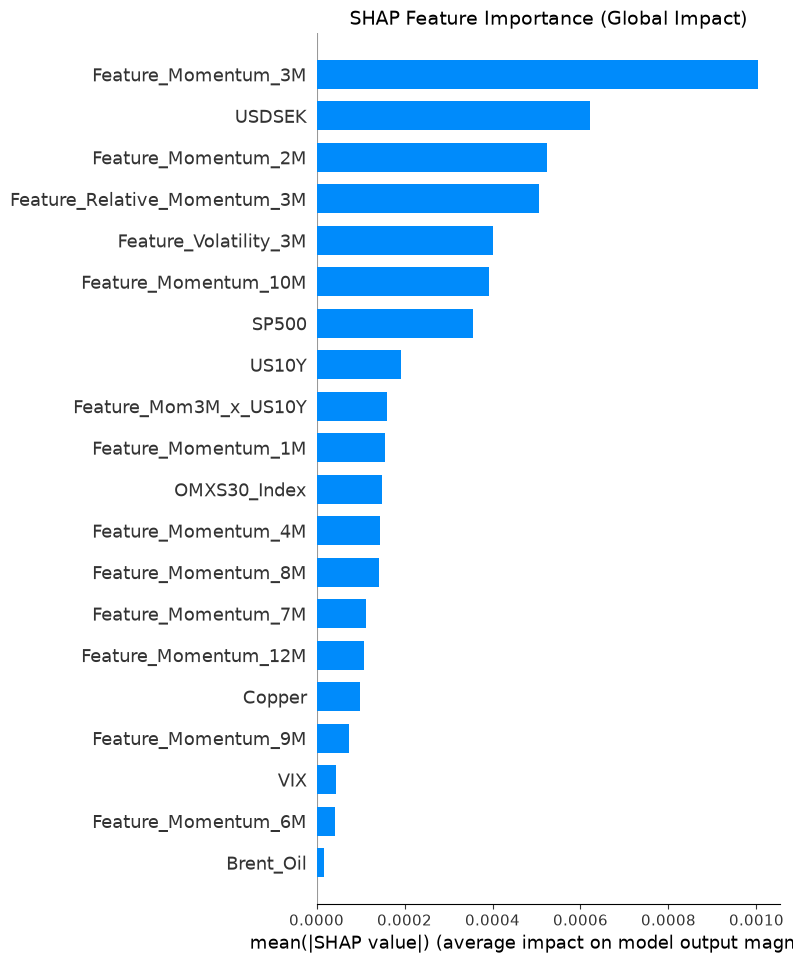

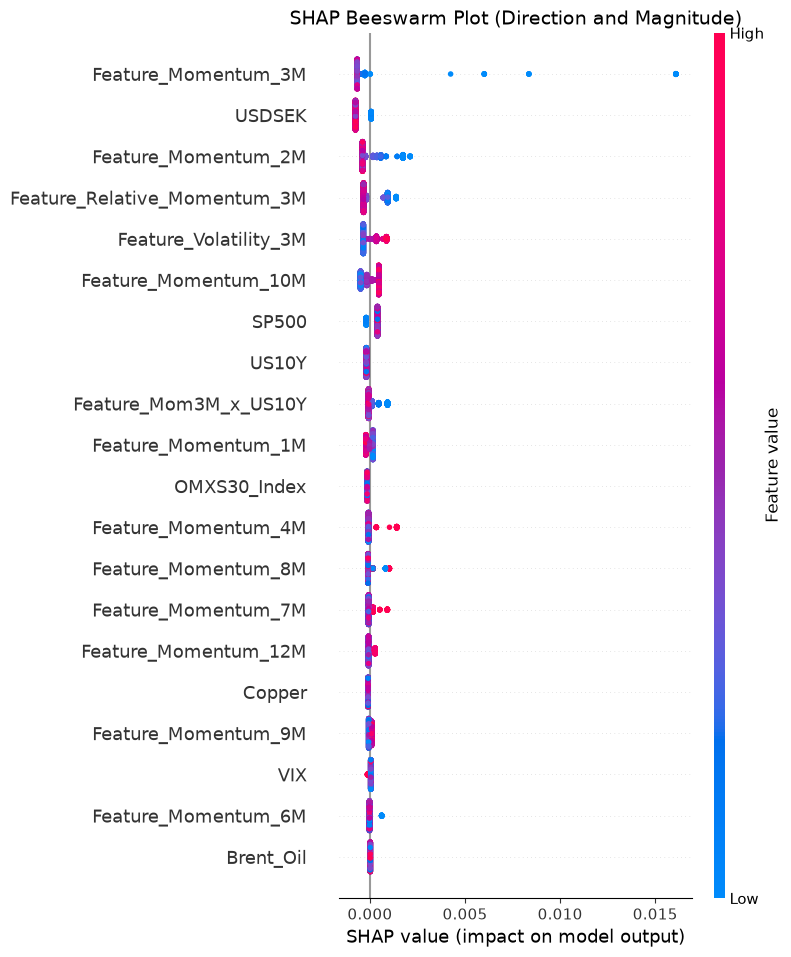

In [11]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values on out-of-sample test data
shap_values = explainer.shap_values(X_test_xgb_scaled_df)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_xgb_scaled_df, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global Impact)", fontsize=14)
plt.show()

# Beeswarm plot (direction and magnitude)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_xgb_scaled_df, show=False)
plt.title("SHAP Beeswarm Plot (Direction and Magnitude)", fontsize=14)
plt.show()